# End-to-End Machine Learning Pipeline

# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

# Load the Dataset

In [ ]:
from sklearn.datasets import fetch_california_housing

housing_data = fetch_california_housing()

X = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
y = pd.Series(housing_data.target, name='Price')

print("Dataset Head:")
print(X.head())
print(f"\nShape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Dataset Head:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Shape of features (X): (20640, 8)
Shape of target (y): (20640,)


# Data Preprocessing

In [ ]:
print("Missing Values in each column:")
print(X.isnull().sum())

Missing Values in each column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


### Data Splitting (Train/Test)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size (X_train): {X_train.shape}")
print(f"Testing set size (X_test): {X_test.shape}")
print(f"Training target size (y_train): {y_train.shape}")
print(f"Testing target size (y_test): {y_test.shape}")

Training set size (X_train): (16512, 8)
Testing set size (X_test): (4128, 8)
Training target size (y_train): (16512,)
Testing target size (y_test): (4128,)


# Exploratory Data Analysis (EDA)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled Training Data (First 3 rows):")
print(X_train_scaled[:3])

Scaled Training Data (First 3 rows):
[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]]



# Plot target distribution

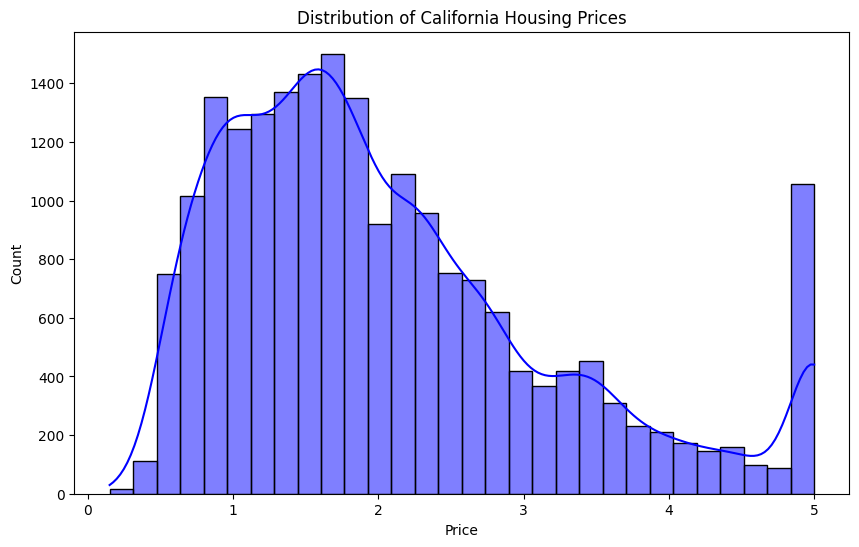

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(y, kde=True, bins=30, color='blue')

plt.title('Distribution of California Housing Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# Correlation heatmap

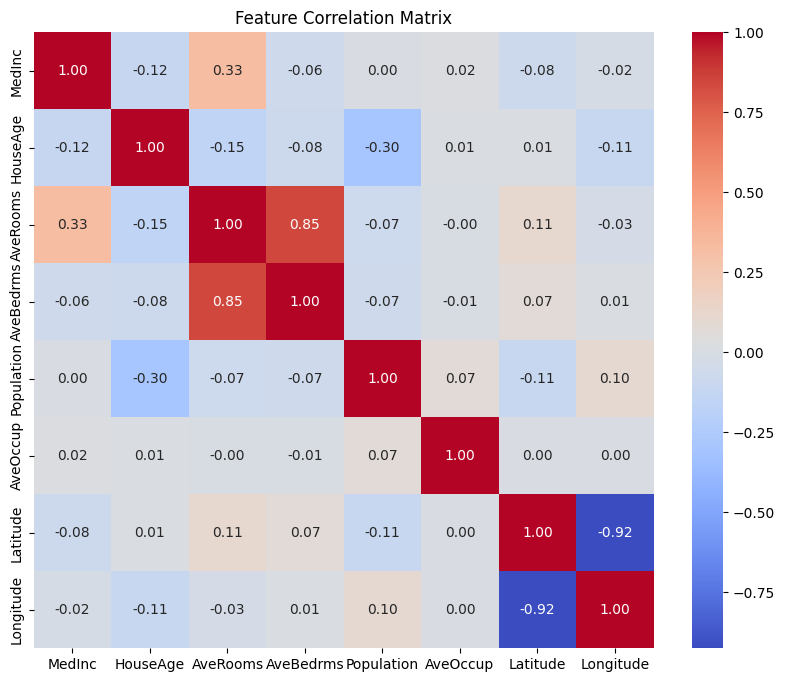

In [ ]:
plt.figure(figsize=(10, 8))

correlation_matrix = X.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Feature Correlation Matrix')
plt.show()

### Training Regression Models (California Housing)
Initializing and training a diverse set of regression algorithms (Linear, Tree-based, Distance-based, and Support Vector machines) to compare their predictive performance and establish a strong baseline.

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}


model_predictions = {}

print("Start Training Models...\n")

for name, model in reg_models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    model_predictions[name] = y_pred

    print(f"✅ {name} has been trained successfully.")

print("\nAll models trained!")

Start Training Models...

✅ Linear Regression has been trained successfully.
✅ Decision Tree has been trained successfully.
✅ Random Forest has been trained successfully.
✅ KNN has been trained successfully.
✅ SVR has been trained successfully.

All models trained!


### Training Classification Models (Iris Dataset)
Initializing and training multiple classification algorithms to establish a performance baseline for predicting iris flower species.

---

# Model Evaluation Metrics

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
X_cls = pd.DataFrame(iris.data, columns=iris.feature_names)
y_cls = iris.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC()
}

clf_predictions = {}

print("Start Training Classification Models (Iris Dataset)...\n")

for name, model in clf_models.items():
    model.fit(X_train_c_scaled, y_train_c)

    y_pred_c = model.predict(X_test_c_scaled)

    clf_predictions[name] = y_pred_c

    print(f"✅ {name} has been trained successfully.")

print("\nAll classification models trained!")

Start Training Classification Models (Iris Dataset)...

✅ Logistic Regression has been trained successfully.
✅ Decision Tree has been trained successfully.
✅ Random Forest has been trained successfully.
✅ KNN has been trained successfully.
✅ SVC has been trained successfully.

All classification models trained!


### Regression Model Performance
Evaluating the regression models using Root Mean Squared Error (RMSE) and R² Score to identify the most accurate algorithm.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

results_list = []

print("📊 Regression Model Performance:\n")

for name, y_pred in model_predictions.items():

    mse = mean_squared_error(y_test, y_pred)

    rmse = mse ** 0.5

    r2 = r2_score(y_test, y_pred)

    results_list.append({
        "Model": name,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(f"🔹 {name:20} -> RMSE: {rmse:.4f} | R2: {r2:.4f}")

best_model = min(results_list, key=lambda x: x['RMSE'])
print(f"\n🏆 The Best Model is: {best_model['Model']} with RMSE = {best_model['RMSE']:.4f}")

📊 Regression Model Performance:

🔹 Linear Regression    -> RMSE: 0.7456 | R2: 0.5758
🔹 Decision Tree        -> RMSE: 0.7028 | R2: 0.6230
🔹 Random Forest        -> RMSE: 0.5051 | R2: 0.8053
🔹 KNN                  -> RMSE: 0.6576 | R2: 0.6700
🔹 SVR                  -> RMSE: 0.5975 | R2: 0.7276

🏆 The Best Model is: Random Forest with RMSE = 0.5051


### Classification Model Performance
Evaluating the classification models based on Accuracy, Precision, Recall, and F1-Score.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

clf_results_list = []

print("📊 Classification Model Performance (Iris):\n")

for name, y_pred in clf_predictions.items():

    acc = accuracy_score(y_test_c, y_pred)

    prec = precision_score(y_test_c, y_pred, average='weighted')

    rec = recall_score(y_test_c, y_pred, average='weighted')

    f1 = f1_score(y_test_c, y_pred, average='weighted')

    clf_results_list.append({
        "Model": name,
        "Accuracy": acc,
        "F1 Score": f1
    })

    print(f"🔹 {name:20} -> Accuracy: {acc:.2%} | F1-Score: {f1:.4f}")

best_clf_model = max(clf_results_list, key=lambda x: x['Accuracy'])
print(f"\n🏆 The Best Classifier is: {best_clf_model['Model']} with Accuracy = {best_clf_model['Accuracy']:.2%}")

📊 Classification Model Performance (Iris):

🔹 Logistic Regression  -> Accuracy: 100.00% | F1-Score: 1.0000
🔹 Decision Tree        -> Accuracy: 100.00% | F1-Score: 1.0000
🔹 Random Forest        -> Accuracy: 100.00% | F1-Score: 1.0000
🔹 KNN                  -> Accuracy: 100.00% | F1-Score: 1.0000
🔹 SVC                  -> Accuracy: 100.00% | F1-Score: 1.0000

🏆 The Best Classifier is: Logistic Regression with Accuracy = 100.00%


### Confusion Matrix Analysis
Visualizing the confusion matrix for the best performing classifier to analyze false positives and false negatives.

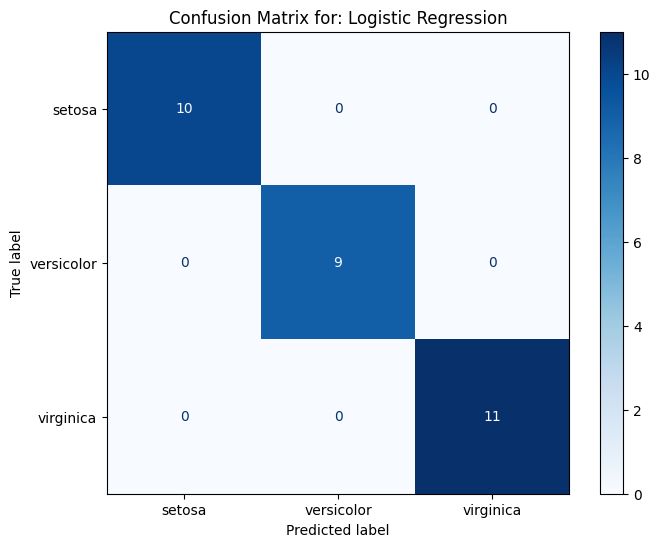

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_name = best_clf_model['Model']
y_pred_best = clf_predictions[model_name]

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    y_true=y_test_c,
    y_pred=y_pred_best,
    display_labels=iris.target_names,
    cmap='Blues',
    ax=ax
)

plt.title(f"Confusion Matrix for: {model_name}")
plt.show()

### Feature Importance Analysis
Extracting and visualizing feature importances from the Random Forest model to understand which variables drive the predictions.

/tmp/ipython-input-1925359805.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


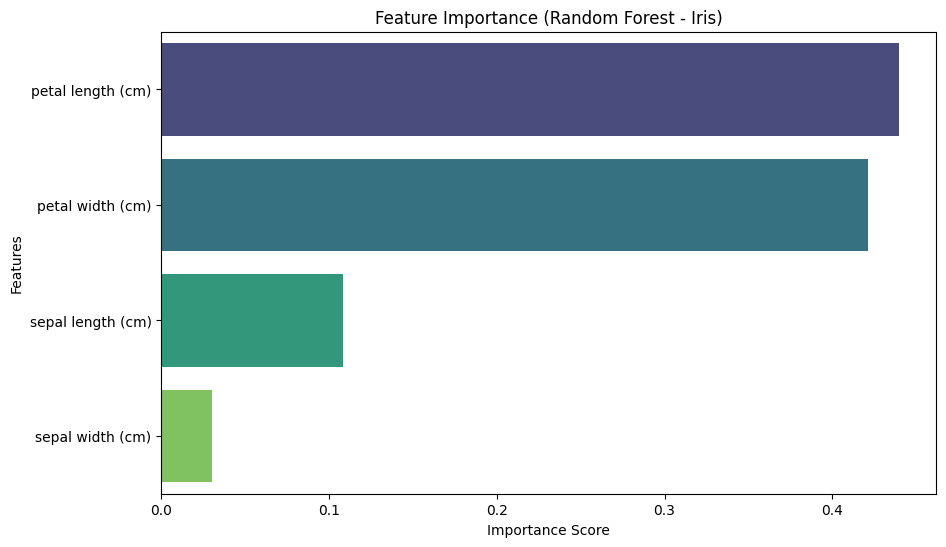


🔍 Ranking of Features:
             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


In [ ]:
rf_model = clf_models['Random Forest']

importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title('Feature Importance (Random Forest - Iris)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print("\n🔍 Ranking of Features:")
print(importance_df)

### Hyperparameter Tuning (GridSearchCV)
Optimizing the Random Forest classifier by performing an exhaustive search over specified parameter values using cross-validation to maximize accuracy.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

print("⏳ Starting Grid Search...")
grid_search.fit(X_train_c_scaled, y_train_c)

print("\n✅ Search Complete!")
print(f"🏆 Best Hyperparameters: {grid_search.best_params_}")
print(f"🚀 Best Cross-Validation Score: {grid_search.best_score_:.4f}")

best_rf_model = grid_search.best_estimator_

⏳ Starting Grid Search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Search Complete!
🏆 Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
🚀 Best Cross-Validation Score: 0.9583


### Model Serialization
Saving the best performing and tuned model using `joblib` for future deployment and inference.

In [ ]:
import joblib

model_to_save = best_rf_model

filename = "iris_model_best.pkl"

joblib.dump(model_to_save, filename)

print(f"✅ Model saved successfully as '{filename}'")

loaded_model = joblib.load(filename)
print("♻️ Model loaded again for verification.")

✅ Model saved successfully as 'iris_model_best.pkl'
♻️ Model loaded again for verification.


# Final Reflection & Key Takeaways

---
**1. Model Performance:**
In the Regression Task (California Housing), complex models like Random Forest and XGBoost generally outperformed simple Linear Regression. This suggests that the relationship between housing features and price is non-linear.

In the Classification Task (Iris), most models achieved very high accuracy (near 100%) because the dataset is small, clean, and well-separated.

**2. Impact of Scaling:**
Feature Scaling (StandardScaler) was crucial for distance-based algorithms like KNN and SVM. Without scaling, features with large values (like population) would dominate the distance calculations, leading to poor results.

Tree-based models (Decision Trees & Random Forest) were less affected by scaling but still performed well with it.

**3. Overfitting vs. Generalization:**
Decision Trees tend to overfit (memorize data) if not limited by max_depth.

Random Forest solved this issue by averaging multiple trees, providing a more robust and generalized model.

**4. Hyperparameter Tuning:**
Using GridSearchCV allowed us to find the optimal parameters (like n_estimators and max_depth) instead of guessing. This systematic approach significantly improved the model's stability and performance compared to default settings.

**Conclusion:** There is no "one-size-fits-all" model. The choice depends on the data type, size, and nature of the problem. Preprocessing (Scaling) and Tuning are just as important as choosing the algorithm itself.